# ABP Modulo 4

**Nicolás Pérez Cerda**
Bootcamp Analisis de datos texto en negrita

In [107]:
import numpy as np #Importar Numpy
import pandas as pd #Importar Pandas
import requests #Para obtener datos de web
import io #Para solventar problema para obtener datos web
import matplotlib.pyplot as plt #Para graficos
import seaborn as sns #Para grafiscos


# Lección 1

In [95]:
# Generar datos ficticios con NumPy
#Semilla para que los numeros random no cambien
np.random.seed(42)
# IDs de clientes (1000 a 1100)
ids_clientes = np.arange(1000, 1100)

# Montos de transacciones (entre 10 y 5000 USD)
# Generamos algunos valores outliers a proposito
transacciones = np.random.uniform(10, 500, size=100)
transacciones[0] = 5000  # Outlier
transacciones[1] = 4800  # Outlier

# 2. Operaciones matemáticas básicas
media_transacciones = np.mean(transacciones) #Promedio transaciones
total_ventas = np.sum(transacciones) # Suma transacciones
conteo = np.size(transacciones) #Conteo de transacciones

print(f"Media: {media_transacciones:.2f}")
print(f"Total: {total_ventas:.2f}")
print(f"Cantidad: {conteo}")

# 3. Guardar datos
datos_numpy = np.array(list(zip(ids_clientes, transacciones)))
np.save('datos_iniciales.npy', datos_numpy)
print("-------------------------")
print(datos_numpy)



Media: 331.69
Total: 33169.48
Cantidad: 100
-------------------------
[[1000.         5000.        ]
 [1001.         4800.        ]
 [1002.          368.67703149]
 [1003.          303.34265726]
 [1004.           86.44913382]
 [1005.           86.43731496]
 [1006.           38.46096996]
 [1007.          434.42631143]
 [1008.          304.54635575]
 [1009.          356.95556312]
 [1010.           20.0864022 ]
 [1011.          485.25582756]
 [1012.          417.89689399]
 [1013.          114.04616423]
 [1014.           99.09423393]
 [1015.           99.86820983]
 [1016.          159.07869905]
 [1017.          267.1306515 ]
 [1018.          221.65305913]
 [1019.          152.7022787 ]
 [1020.          309.80791841]
 [1021.           78.35199172]
 [1022.          153.15087778]
 [1023.          189.51730321]
 [1024.          233.47429227]
 [1025.          394.73622108]
 [1026.          107.84015326]
 [1027.          261.97487482]
 [1028.          300.28313874]
 [1029.           32.76070223]


#Lección 2

In [96]:
# Leer los datos de generados anteriormente
#Convertir a Arreglo en Dataframe

datos_iniciales = np.load('datos_iniciales.npy')#Carga de datos
df_inicial = pd.DataFrame(datos_iniciales, columns=['ID_Cliente', 'Monto_Transaccion'])

#Mostrar Dataframe
print("Dataframe")
display(df_inicial)

print("\n--- Estadísticas Descriptivas ---")
display(df_inicial.describe())

# 3Filtro condicional: Transacciones mayores a 100
df_filtrado = df_inicial[df_inicial['Monto_Transaccion'] > 100]
print("Transacciones mayores a 100")
display(df_filtrado)

# 4. Guardar datos
df_inicial.to_csv('dataframe_preliminar.csv', index=False)

Dataframe


,ID_Cliente,Monto_Transaccion
0,1000.0,5000.000000
1,1001.0,4800.000000
2,1002.0,368.677031
3,1003.0,303.342657
4,1004.0,86.449134
...,...,...
95,1095.0,251.959842
96,1096.0,266.139086
97,1097.0,219.495099
98,1098.0,22.455372



--- Estadísticas Descriptivas ---


,ID_Cliente,Monto_Transaccion
count,100.000000,100.000000
mean,1049.500000,331.694818
std,29.011492,671.620014
min,1000.000000,12.705837
25%,1024.750000,104.668373
50%,1049.500000,246.672578
75%,1074.250000,372.203942
max,1099.000000,5000.000000


Transacciones mayores a 100


,ID_Cliente,Monto_Transaccion
0,1000.0,5000.000000
1,1001.0,4800.000000
2,1002.0,368.677031
3,1003.0,303.342657
7,1007.0,434.426311
...,...,...
93,1093.0,285.025827
94,1094.0,387.773918
95,1095.0,251.959842
96,1096.0,266.139086


# Lección 3
Union de datos

In [97]:
#cARGA DE DATAFRAMES
display(df_inicial)
print("-------Lectura CSV----------- ")
df_csv = pd.read_csv('clientes_ecommerce.csv')
display(df_csv)
print("--------Lectura Excel---------- ")
excel = pd.read_excel("clientes_ecommerce.xlsx")
display(excel)
print("--------Tabla web---------- ")
# 1. URL del archivo de datos (Directo desde GitHub) costo lograr obtener datos
# 1. FUENTE WEB ESTABLE (GitHub - No bloquea)
url_web = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

try:
    # Leemos solo las columnas que nos sirven como "información extra"
    df_web = pd.read_csv(url_web)[['PassengerId', 'Pclass', 'Fare']]
    # RENOMBRAMOS para poder unir con tus archivos locales
    df_web.rename(columns={'PassengerId': 'ID'}, inplace=True)
    print("✅ Tabla web obtenida exitosamente de GitHub.")
except Exception as e: #Por si da error
    print(f"❌ Error: {e}")

display(df_web)

,ID_Cliente,Monto_Transaccion
0,1000.0,5000.000000
1,1001.0,4800.000000
2,1002.0,368.677031
3,1003.0,303.342657
4,1004.0,86.449134
...,...,...
95,1095.0,251.959842
96,1096.0,266.139086
97,1097.0,219.495099
98,1098.0,22.455372


-------Lectura CSV----------- 


,ID,Nombre,Edad,Ciudad,Total_Compras,Monto_Total
0,1,Ana,25.0,Buenos Aires,5,2500
1,2,Luis,34.0,Córdoba,2,1200
2,3,Carlos,45.0,Rosario,0,0
3,4,Marta,29.0,Mendoza,3,1800
4,5,Jorge,31.0,La Plata,8,3200
5,6,Lucía,28.0,Salta,10,4100
6,7,Pedro,NaN,Tucumán,1,400
7,8,Sofía,33.0,Santa Fe,4,2100
8,9,Diego,42.0,Neuquén,7,3300
9,10,Valentina,30.0,Bahía Blanca,6,2950


--------Lectura Excel---------- 


,ID,Nombre,Edad,Ciudad,Total_Compras,Monto_Total
0,1,Ana,25.0,Buenos Aires,5,2500
1,2,Luis,34.0,Córdoba,2,1200
2,3,Carlos,45.0,Rosario,0,0
3,4,Marta,29.0,Mendoza,3,1800
4,5,Jorge,31.0,La Plata,8,3200
5,6,Lucía,28.0,Salta,10,4100
6,7,Pedro,NaN,Tucumán,1,400
7,8,Sofía,33.0,Santa Fe,4,2100
8,9,Diego,42.0,Neuquén,7,3300
9,10,Valentina,30.0,Bahía Blanca,6,2950


--------Tabla web---------- 
✅ Tabla web obtenida exitosamente de GitHub.


,ID,Pclass,Fare
0,1,3,7.2500
1,2,1,71.2833
2,3,3,7.9250
3,4,1,53.1000
4,5,3,8.0500
...,...,...,...
886,887,2,13.0000
887,888,1,30.0000
888,889,3,23.4500
889,890,1,30.0000


In [98]:
df_inicial.rename(columns={
    'ID_Cliente': 'ID',
    'Monto_Transaccion': 'Monto_Total'
}, inplace=True)

In [99]:
# Union CSV + Excel
df_locales = pd.merge(df_csv, excel, on='ID', how='outer', suffixes=('', '_dup'))
df_locales = df_locales.loc[:, ~df_locales.columns.str.contains('_dup')]
display(df_locales)

,ID,Nombre,Edad,Ciudad,Total_Compras,Monto_Total
0,1,Ana,25.0,Buenos Aires,5,2500
1,2,Luis,34.0,Córdoba,2,1200
2,3,Carlos,45.0,Rosario,0,0
3,4,Marta,29.0,Mendoza,3,1800
4,5,Jorge,31.0,La Plata,8,3200
5,6,Lucía,28.0,Salta,10,4100
6,7,Pedro,NaN,Tucumán,1,400
7,8,Sofía,33.0,Santa Fe,4,2100
8,9,Diego,42.0,Neuquén,7,3300
9,10,Valentina,30.0,Bahía Blanca,6,2950


In [113]:
df_union_dataframe = pd.merge(
    df_locales,
    df_inicial[['ID', 'Monto_Total']],
    on='ID',
    how='outer',
    suffixes=('', '_NumPy')
)

# Consolidamos en una sola columna
# Como los IDs no se solapan, esto "rellena" los huecos del CSV con los datos de NumPy
df_union_dataframe['Monto_Total'] = (
    df_union_dataframe['Monto_Total'].fillna(0) +
    df_union_dataframe['Monto_Total_NumPy'].fillna(0)
)

# Limpiamos la columna temporal y mostramos
df_union_dataframe.drop(columns=['Monto_Total_NumPy'], inplace=True)

display(df_union_dataframe.head(15))
df_union_dataframe.info()

,ID,Nombre,Edad,Ciudad,Total_Compras,Monto_Total
0,1.0,Ana,25.0,Buenos Aires,5.0,2500.000000
1,2.0,Luis,34.0,Córdoba,2.0,1200.000000
2,3.0,Carlos,45.0,Rosario,0.0,0.000000
3,4.0,Marta,29.0,Mendoza,3.0,1800.000000
4,5.0,Jorge,31.0,La Plata,8.0,3200.000000
5,6.0,Lucía,28.0,Salta,10.0,4100.000000
6,7.0,Pedro,NaN,Tucumán,1.0,400.000000
7,8.0,Sofía,33.0,Santa Fe,4.0,2100.000000
8,9.0,Diego,42.0,Neuquén,7.0,3300.000000
9,10.0,Valentina,30.0,Bahía Blanca,6.0,2950.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             110 non-null    float64
 1   Nombre         10 non-null     object 
 2   Edad           9 non-null      float64
 3   Ciudad         10 non-null     object 
 4   Total_Compras  10 non-null     float64
 5   Monto_Total    110 non-null    float64
dtypes: float64(4), object(2)
memory usage: 5.3+ KB


In [114]:
df_final = pd.merge(df_union_dataframe, df_web, on='ID', how='left')

display(df_final)

,ID,Nombre,Edad,Ciudad,Total_Compras,Monto_Total,Pclass,Fare
0,1.0,Ana,25.0,Buenos Aires,5.0,2500.000000,3.0,7.2500
1,2.0,Luis,34.0,Córdoba,2.0,1200.000000,1.0,71.2833
2,3.0,Carlos,45.0,Rosario,0.0,0.000000,3.0,7.9250
3,4.0,Marta,29.0,Mendoza,3.0,1800.000000,1.0,53.1000
4,5.0,Jorge,31.0,La Plata,8.0,3200.000000,3.0,8.0500
...,...,...,...,...,...,...,...,...
105,1095.0,NaN,NaN,NaN,NaN,251.959842,NaN,NaN
106,1096.0,NaN,NaN,NaN,NaN,266.139086,NaN,NaN
107,1097.0,NaN,NaN,NaN,NaN,219.495099,NaN,NaN
108,1098.0,NaN,NaN,NaN,NaN,22.455372,NaN,NaN


# Lección 4

In [115]:
# Gestión de Valores Nulos
#Convertir ID en entero
df_final['ID'] = df_final['ID'].astype(int)
# Establecer ID como el índice principal
df_final.set_index('ID', inplace=True)
# Llenamos la Edad con la mediana
df_final['Edad'] = df_final['Edad'].fillna(df_final['Edad'].median())

# Llenamos datos categóricos con etiquetas descriptivas
df_final['Ciudad'] = df_final['Ciudad'].fillna('Desconocido')
df_final['Nombre'] = df_final['Nombre'].fillna('Anónimo')

# Aseguramos que los valores numéricos de compras no sean nulos
df_final['Total_Compras'] = df_final['Total_Compras'].fillna(0)
df_final['Monto_Total'] = df_final['Monto_Total'].fillna(0)
#Eliminación de columnas innecesarias
df_final.drop(columns=['Pclass', 'Fare'], inplace=True, errors='ignore')
#Convertir EDAD en entero
df_final['Edad'] = df_final['Edad'].astype(int)
#Rellenar datos faltantes en monto compra
# 1Calculamos la mediana de los que SÍ tienen monto (para que sea un valor real)
# Filtramos los montos mayores a 0 para calcular una mediana
mediana_monto = df_final[df_final['Monto_Total'] > 0]['Monto_Total'].median()

# Reemplazamos los ceros por esa mediana
# Lo hacemos para el ID 3 (Rosario) y cualquier otro con monto 0
df_final['Monto_Total'] = df_final['Monto_Total'].replace(0, mediana_monto)

# Si ahora tienen monto, deben tener al menos 1 compra
df_final.loc[(df_final['Monto_Total'] > 0) & (df_final['Total_Compras'] == 0), 'Total_Compras'] = 1

# 4. Redondeamos para que quede estético
df_final['Monto_Total'] = df_final['Monto_Total'].round(2)

print(f"El valor asignado (Mediana) fue: ${mediana_monto:.2f}")
#Monto Total con 2 decimales
df_final['Monto_Total'] = df_final['Monto_Total'].round(2)

display(df_final)


El valor asignado (Mediana) fue: $266.14


,Nombre,Edad,Ciudad,Total_Compras,Monto_Total
ID,,,,,
1,Ana,25,Buenos Aires,5.0,2500.00
2,Luis,34,Córdoba,2.0,1200.00
3,Carlos,45,Rosario,1.0,266.14
4,Marta,29,Mendoza,3.0,1800.00
5,Jorge,31,La Plata,8.0,3200.00
...,...,...,...,...,...
1095,Anónimo,31,Desconocido,1.0,251.96
1096,Anónimo,31,Desconocido,1.0,266.14
1097,Anónimo,31,Desconocido,1.0,219.50


In [116]:
# Cálculo de Outliers con el ID como índice
Q1 = df_final['Monto_Total'].quantile(0.25)
Q3 = df_final['Monto_Total'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

# Identificamos los valores que superan el límite
outliers = df_final[df_final['Monto_Total'] > limite_superior]

print(f"📊 Análisis de Calidad de Datos:")
print(f"Límite máximo de compra normal: ${limite_superior:.2f}")
print(f"Cantidad de valores atípicos encontrados: {len(outliers)}")

# Mostramos los outliers (aquí deberían aparecer los montos de 5000 y 4800 de la Lección 1)
display(outliers)

📊 Análisis de Calidad de Datos:
Límite máximo de compra normal: $832.62
Cantidad de valores atípicos encontrados: 10


,Nombre,Edad,Ciudad,Total_Compras,Monto_Total
ID,,,,,
1,Ana,25,Buenos Aires,5.0,2500.0
2,Luis,34,Córdoba,2.0,1200.0
4,Marta,29,Mendoza,3.0,1800.0
5,Jorge,31,La Plata,8.0,3200.0
6,Lucía,28,Salta,10.0,4100.0
8,Sofía,33,Santa Fe,4.0,2100.0
9,Diego,42,Neuquén,7.0,3300.0
10,Valentina,30,Bahía Blanca,6.0,2950.0
1000,Anónimo,31,Desconocido,1.0,5000.0


### **Lección 5**

In [118]:
# Calculamos la venta Promedio (Monto dividido por cantidad de compras)
# Usamos la columna de Total_Compras
df_final['Venta_promedio'] = (df_final['Monto_Total'] / df_final['Total_Compras']).round(2)

# Vamos a clasificar a los clientes según su gasto total:
# - VIP: Más de 3000
# - Estandar: Entre 1000 y 3000
# - Casual: Menos de 1000
df_final['Tipo_Cliente'] = df_final['Monto_Total'].apply(
    lambda x: 'VIP' if x > 3000 else ('Activo' if x >= 1000 else 'Estándar')
)

# Agrupamos por segmento para ver cuántos clientes hay y cuánto gastan en total
resumen_segmentos = df_final.groupby('Tipo_Cliente').agg({
    'Monto_Total': ['count', 'sum', 'mean']
}).round(2)

print(" Resumen por Segmento de Cliente ")
display(resumen_segmentos)

print("\Vista previa del Dataset Transformado ")
display(df_final.head(10))

 Resumen por Segmento de Cliente 


Monto_Total                   
                   count       sum     mean
Tipo_Cliente                               
Activo                 5  10550.00  2110.00
Estándar             100  24035.65   240.36
VIP                    5  20400.00  4080.00

Vista previa del Dataset Transformado 


,Nombre,Edad,Ciudad,Total_Compras,Monto_Total,Venta_promedio,Tipo_Cliente
ID,,,,,,,
1,Ana,25,Buenos Aires,5.0,2500.00,500.00,Activo
2,Luis,34,Córdoba,2.0,1200.00,600.00,Activo
3,Carlos,45,Rosario,1.0,266.14,266.14,Estándar
4,Marta,29,Mendoza,3.0,1800.00,600.00,Activo
5,Jorge,31,La Plata,8.0,3200.00,400.00,VIP
6,Lucía,28,Salta,10.0,4100.00,410.00,VIP
7,Pedro,31,Tucumán,1.0,400.00,400.00,Estándar
8,Sofía,33,Santa Fe,4.0,2100.00,525.00,Activo
9,Diego,42,Neuquén,7.0,3300.00,471.43,VIP


In [125]:
#PIVOT
df_pivot = df_final.pivot_table(
    values="Monto_Total",
    index="Tipo_Cliente",
    columns="Ciudad",
    aggfunc="sum"
)

display(df_pivot)

Ciudad,Bahía Blanca,Buenos Aires,Córdoba,Desconocido,La Plata,Mendoza,Neuquén,Rosario,Salta,Santa Fe,Tucumán
Tipo_Cliente,,,,,,,,,,,
Activo,2950.0,2500.0,1200.0,NaN,NaN,1800.0,NaN,NaN,NaN,2100.0,NaN
Estándar,NaN,NaN,NaN,23369.51,NaN,NaN,NaN,266.14,NaN,NaN,400.0
VIP,NaN,NaN,NaN,9800.00,3200.0,NaN,3300.0,NaN,4100.0,NaN,NaN


In [126]:
#Melt
df_melt = df_pivot.reset_index().melt(
    id_vars="Tipo_Cliente",
    var_name="Ciudad",
    value_name="Monto_Total"
)

display(df_melt.head())

,Tipo_Cliente,Ciudad,Monto_Total
0,Activo,Bahía Blanca,2950.0
1,Estándar,Bahía Blanca,NaN
2,VIP,Bahía Blanca,NaN
3,Activo,Buenos Aires,2500.0
4,Estándar,Buenos Aires,NaN


# Lección 6

/tmp/ipython-input-852121740.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grafico_barras = sns.barplot(


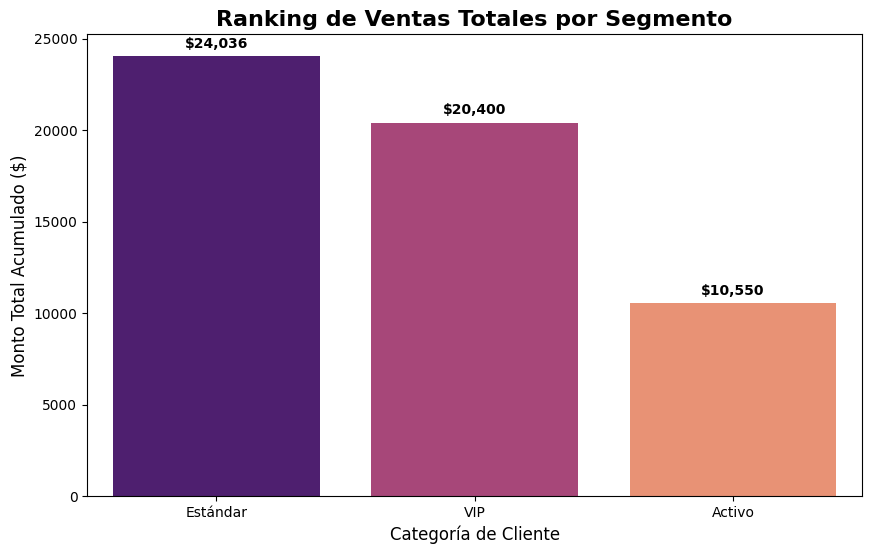

In [112]:
#Calculamos el orden: agrupamos por tipo, sumamos monto y ordenamos de mayor a menor
orden_ventas = df_final.groupby('Tipo_Cliente')['Monto_Total'].sum().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))

# Usamos 'order=orden_ventas' para que se ordene por el dinero total
grafico_barras = sns.barplot(
    data=df_final,
    x='Tipo_Cliente',
    y='Monto_Total',
    estimator=sum,
    palette='magma',
    order=orden_ventas,
    errorbar=None
)

plt.title('Ranking de Ventas Totales por Segmento', fontsize=16, fontweight='bold')
plt.xlabel('Categoría de Cliente', fontsize=12)
plt.ylabel('Monto Total Acumulado ($)', fontsize=12)

# Añadimos las etiquetas de dinero
for p in grafico_barras.patches:
    valor = p.get_height()
    grafico_barras.annotate(f'${valor:,.0f}',
                            (p.get_x() + p.get_width() / 2., valor),
                            ha='center', va='center',
                            xytext=(0, 9),
                            textcoords='offset points',
                            fontsize=10,
                            fontweight='bold')

plt.show()

Se identificó que el segmento Estandar(clientes casuales) Lidera las ventas en monto total de inglesos. Esto se debe aunque sus montos son bajos , son una cantidad considerable de ordenes compensando el monto venta con cantidad de ventas. El segmento VIP es el segundo con mayor cantidades de venta siendo solo 5 clientes generan casi la misma cantidad de ingresos que los estandar demostrando una alta eficiencia en el total de compras. Luego los clientes activos estan por muy por debajo del resto lo que sugiere una oportunidad de negocio

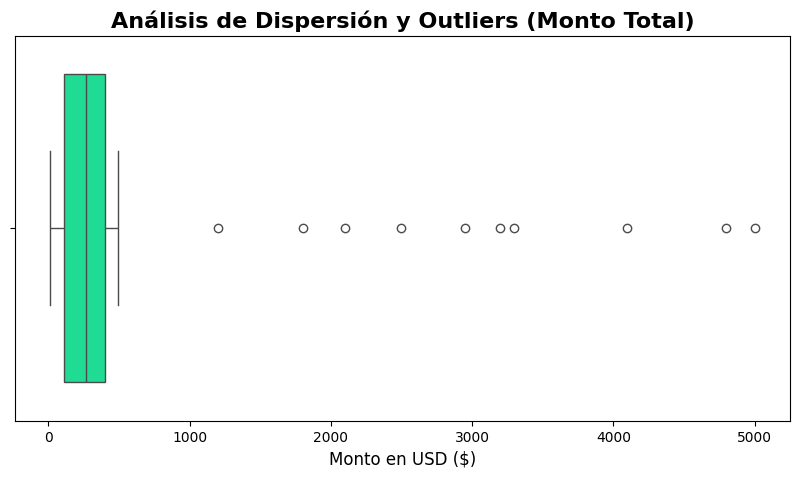

In [109]:
# 2. Boxplot de Monto_Total
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final['Monto_Total'], color='mediumspringgreen')

plt.title('Análisis de Dispersión y Outliers (Monto Total)', fontsize=16, fontweight='bold')
plt.xlabel('Monto en USD ($)', fontsize=12)

plt.show()

# Analisis de Boxplot

El diagrama de caja revela una asimetría de ventas importante. La base de la caja y el bigote inferior cercanos a valores minimos confirman la existencia de un volumen masivo de clientes con transacciones mínimas, mientras que los puntos aislados en el extremo derecho validan la presencia de clientes VIP con un comportamiento de compra extremandamente altos

In [127]:
# Guardar el data set final en formato CSV
df_final.to_csv('clientes_analisis_final.csv', index=True)
# Guardar el data set final en formato Excel
df_final.to_excel("dataset_final.xlsx", index=False)
